In [1]:
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import yfinance as yf

As documented in writing in 2024

In [2]:
symbols = [
    "BA",
    "INTC",
    "LPLA",
    "MU",
    "^GSPC"
]

START = "2024-06-28"
END = None

signal = yf.download(symbols, start=START, end=END)["Close"].dropna()

eq = signal[symbols[:-1]]

ix = signal[symbols[-1]]

def correlation(m, n):
    c = np.corrcoef(m, n)[0][1]
    if not np.isnan(c):
      return c
    return 0

/var/folders/mq/f_2xhb9d4xv13xb4888zcc_80000gn/T/ipykernel_2956/4275315225.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  signal = yf.download(symbols, start=START, end=END)["Close"].dropna()
[*********************100%***********************]  5 of 5 completed


In [3]:
n1 = 40
n2 = 65
n3 = 149
n4 = 24

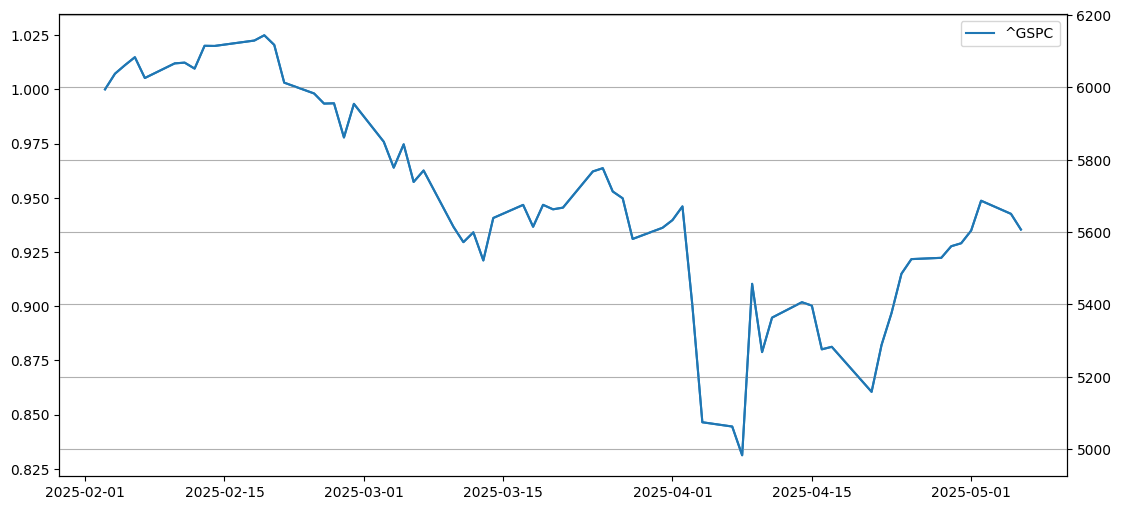

In [4]:
fig, ax = plt.subplots(figsize=(13,6))
ax.plot(ix.iloc[n3: n3 + n2] / ix.iloc[n3], label=symbols[-1])
ax_ = ax.twinx()
ax_.plot(ix.iloc[n3: n3 + n2], label=symbols[-1])
plt.grid()
plt.legend()
plt.show()

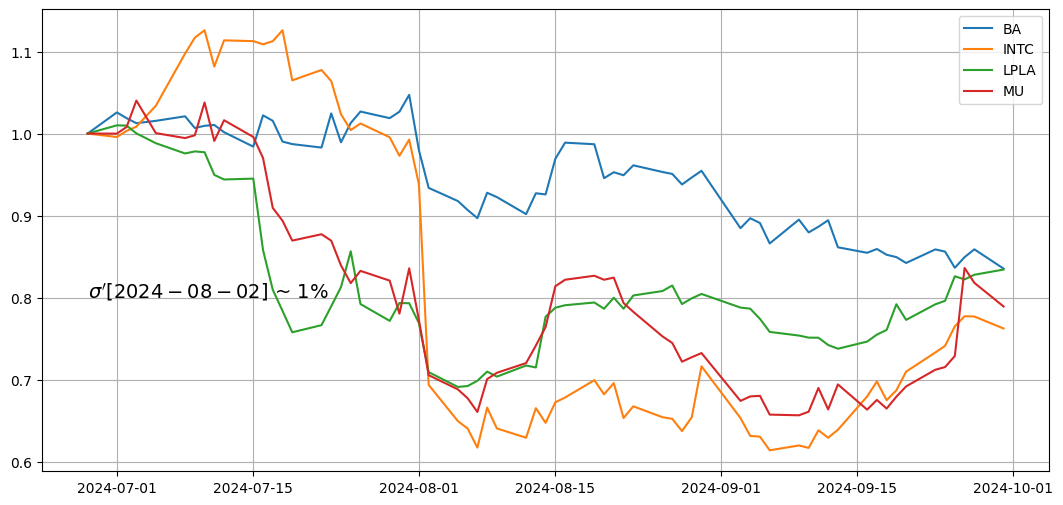

In [5]:
plt.figure(figsize=(13,6))
plt.plot(eq.iloc[:n2] / eq.iloc[0], label=eq.columns)
plt.text(eq.index[0], 0.8, f"$\\sigma'[{eq.index[n4]}]$ ~ {100 * (eq.iloc[n4] / eq.iloc[0]).drop("BA").std():.0f}%".replace("00:00:00", ""), fontsize=14)
plt.grid()
plt.legend()
plt.show()

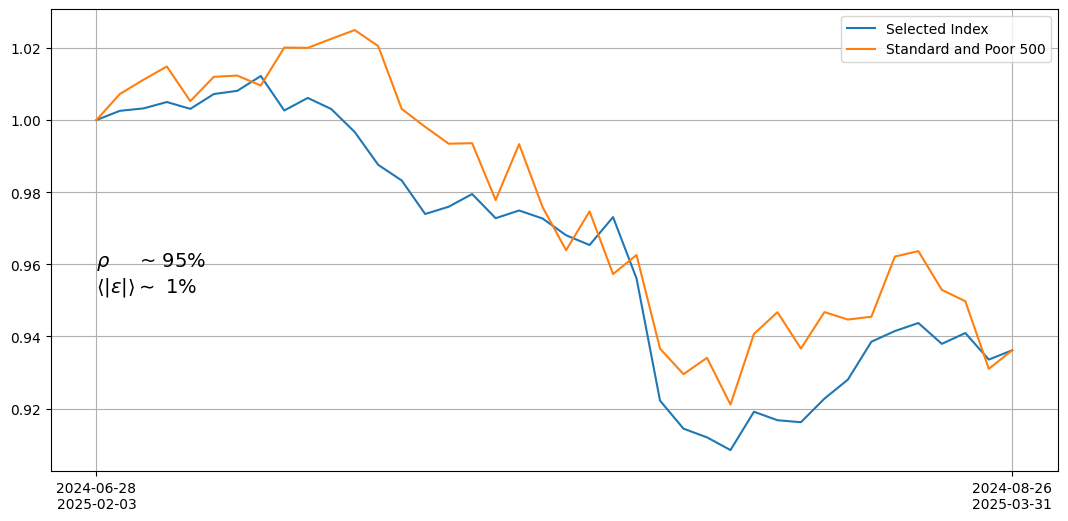

In [6]:
plt.figure(figsize=(13,6))
x, y = np.array((eq.iloc[:n1] / eq.iloc[0]).mean(axis=1)).flatten(), np.array(ix.iloc[n3: n3 + n1] / ix.iloc[n3]).flatten()
x = 1 + (x - 1) * (y[-1] - 1) / (x[-1] - 1)
plt.plot(x, label="Selected Index")
plt.plot(y, label="Standard and Poor 500")
rho = correlation(x, y)
MAE = np.mean(np.abs(x - y))
plt.text(0, rho, f"$\\rho$     ~ {100 * rho:.0f}%\n$\\langle|\\epsilon|\\rangle \\sim$ {100 * MAE:.0f}%", fontsize=14)
dates = ["2024-06-28\n2025-02-03", "2024-08-26\n2025-03-31"]
plt.xticks([0, n1 -1], dates)
plt.grid()
plt.legend()
plt.show()

24-11-2025

Tijuana, Baja California, Mexico